In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np 
import pandas as pd

import os


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


2026-02-02 15:43:00.987656: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770046981.250514      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770046981.322324      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770046981.925966      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770046981.926012      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770046981.926015      17 computation_placer.cc:177] computation placer alr

In [3]:
np.random.seed(42)


m_true = 3 
b_true = 10
x = np.random.rand(1000, 1) * 10 
noise = np.random.normal(0, 2, size=(1000, 1))
y = m_true * x + b_true + noise


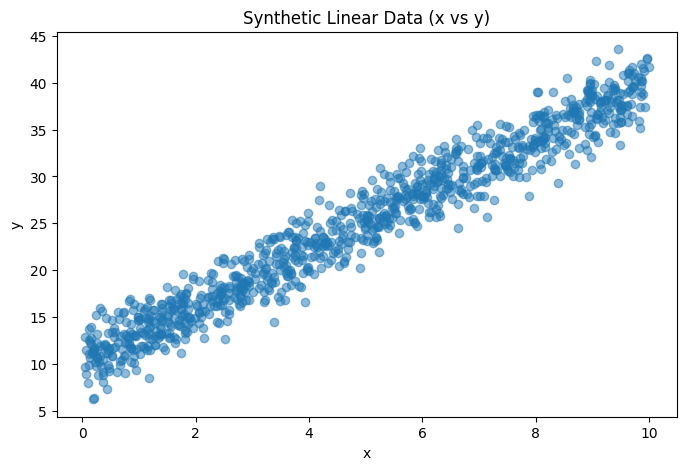

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Linear Data (x vs y)")
plt.show()


In [5]:

x_train, x_test, y_train, y_test = train_test_split(
    x,          
    y,          
    test_size=0.2, 
    random_state=42 
)

In [6]:
model = Sequential([
    Dense(1, input_shape=(1,))
])
print("Model Architecture:")
print(model.summary())
optimizer=SGD(learning_rate=0.01)
model.compile(
    optimizer=optimizer, 
    loss='mse'
)


Model Architecture:


2026-02-02 15:43:18.199102: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

#loss evaluation
y_test_pred = model.predict(x_test)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse_test:.3f}")

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 233.1512   
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21.6995 
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.0271 
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.8087 
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.0902
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.3529 
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2638  
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.7665 
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0150 
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2962 
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8572 
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0065 
Epoch 13/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.3665 
Epoch 14/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.9324 
Epoch 15/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7

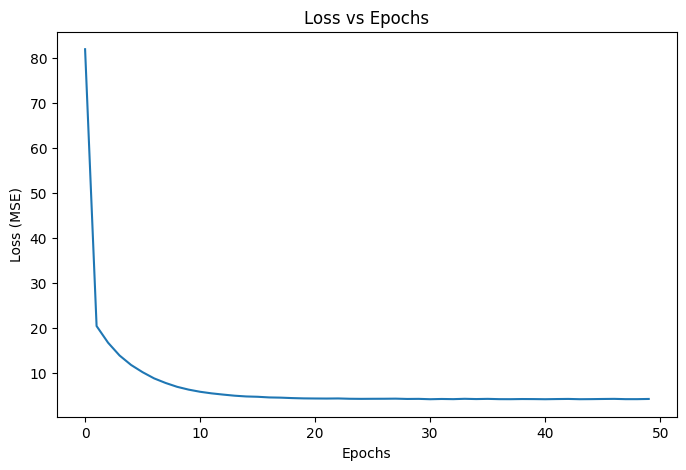

In [8]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.show()


In [9]:
weights, bias = model.layers[0].get_weights()

learned_m = weights[0][0]
learned_b = bias[0]

print(f"True Weight: {m_true}")
print(f"Learned Weight: {learned_m:.4f}")

print(f"\nTrue Bias: {b_true}")
print(f"Learned Bias: {learned_b:.4f}")


True Weight: 3
Learned Weight: 2.9421

True Bias: 10
Learned Bias: 10.3576


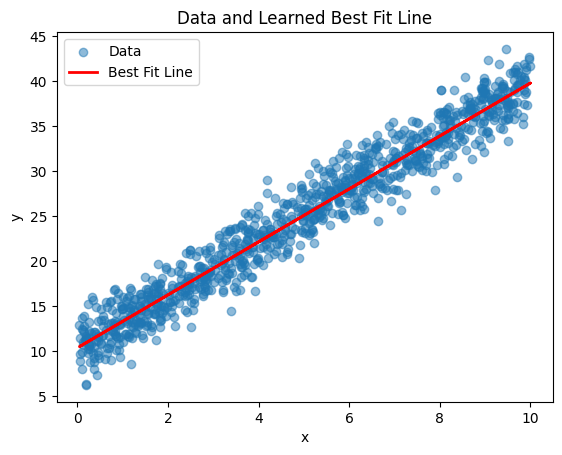

In [10]:
# Overlay best fit line on scatter plot
plt.scatter(x, y, alpha=0.5, label="Data")
y_pred = learned_m * x + learned_b 
plt.plot(x, y_pred, color='red', linewidth=2, label="Best Fit Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data and Learned Best Fit Line")
plt.legend()
plt.show()